# Project 5 — License Plate Deblurring
### Wiener Filter / FFT-based Deconvolution Pipeline

**Course:** Introduction to Computer Vision  
**Dataset:** Kaggle Car Plate Detection (471 real license plate images)

---

## Overview

This notebook implements a complete **blind** motion deblurring pipeline for license plates.
Motion blur occurs when vehicles move during camera exposure, making plates unreadable.
We apply frequency-domain deconvolution using the Wiener filter to reverse this effect.

| Section | Description |
|---|---|
| 1 | Dataset loading & plate cropping |
| 2 | Train / validation split |
| 3 | Synthetic blur generation |
| 4 | FFT magnitude analysis |
| 5 | CNN-based PSF estimation |
| 6 | Wiener filter |
| 7 | K parameter sweep |
| 8 | Evaluation — ground truth PSF (upper bound) |
| 9 | Evaluation — CNN blind pipeline |
| 10 | Results visualization |
| 11 | Method comparison |
| 12 | Results summary |

In [1]:
# ═══════════════════════════════════════
# IMPORTS & SETUP
# ═══════════════════════════════════════
import numpy as np
import cv2
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy.signal import convolve2d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random

random.seed(42)
np.random.seed(42)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Environment ready ✅')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)

Environment ready ✅
PyTorch: 2.8.0
Device: mps


## Section 1 — Dataset Loading

We use the **Kaggle Car Plate Detection** dataset containing 433 real car photos
with Pascal VOC XML annotations marking each license plate bounding box.
Each plate region is cropped and resized to a standard **224×64 pixel** format.
This yields 471 license plate crops total.

Images folder   : /Users/yahya/Project5/data/archive/images
Annotations     : /Users/yahya/Project5/data/archive/annotations
Images found    : 433
Total plate crops loaded: 471


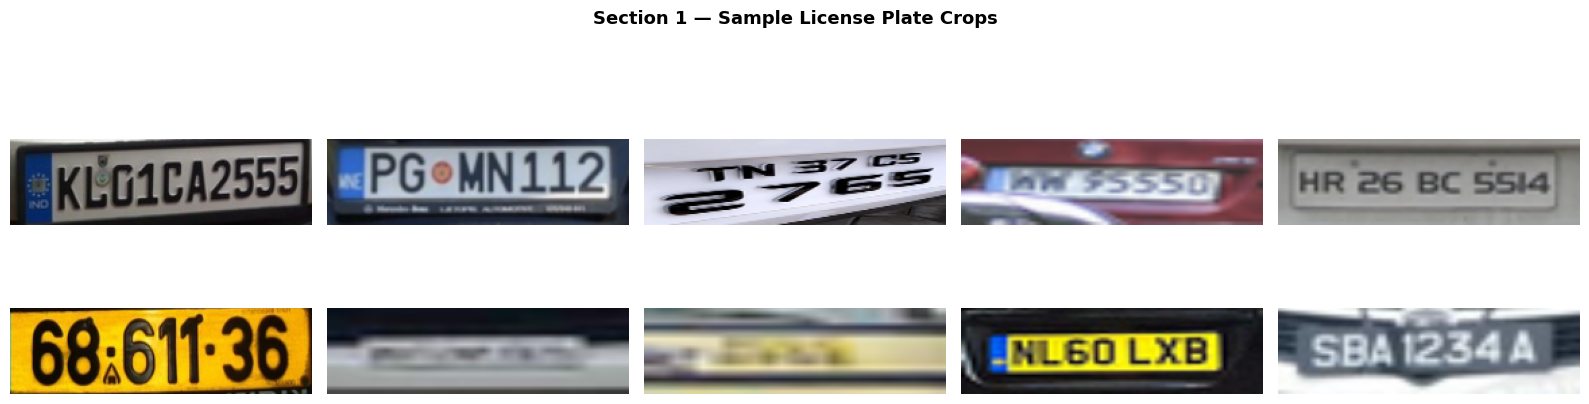

In [2]:
# ═══════════════════════════════════════
# SECTION 1 — DATASET LOADING
# ═══════════════════════════════════════

REPO_ROOT  = Path.cwd()
IMG_DIR    = REPO_ROOT / 'data' / 'archive' / 'images'
ANN_DIR    = REPO_ROOT / 'data' / 'archive' / 'annotations'
OUTPUT_DIR = REPO_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Images folder   :', IMG_DIR)
print('Annotations     :', ANN_DIR)
print('Images found    :', len(list(IMG_DIR.glob('*.png')) + list(IMG_DIR.glob('*.jpg'))))

def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall('object'):
        bndbox = obj.find('bndbox')
        x1 = int(float(bndbox.find('xmin').text))
        y1 = int(float(bndbox.find('ymin').text))
        x2 = int(float(bndbox.find('xmax').text))
        y2 = int(float(bndbox.find('ymax').text))
        boxes.append((x1, y1, x2, y2))
    return boxes

def load_plate_crops(img_dir, ann_dir, target_size=(224, 64)):
    crops = []
    img_files = sorted(list(Path(img_dir).glob('*.png')) + list(Path(img_dir).glob('*.jpg')))
    for img_path in img_files:
        xml_path = Path(ann_dir) / (img_path.stem + '.xml')
        if not xml_path.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        for (x1, y1, x2, y2) in parse_annotation(xml_path):
            pad = 5
            h, w = img.shape[:2]
            x1 = max(0, x1-pad); y1 = max(0, y1-pad)
            x2 = min(w, x2+pad); y2 = min(h, y2+pad)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            crops.append(cv2.resize(crop, target_size))
    return crops

crops = load_plate_crops(IMG_DIR, ANN_DIR)
print(f'Total plate crops loaded: {len(crops)}')

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
fig.suptitle('Section 1 — Sample License Plate Crops', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(crops):
        ax.imshow(cv2.cvtColor(crops[i], cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 2 — Train / Validation Split

The dataset is split **80/20** into training and validation sets using a fixed
random seed (42) for reproducibility.  
The training set is used to tune parameters and train the CNN.  
The validation set is used **only** for final evaluation.

In [3]:
# ═══════════════════════════════════════
# SECTION 2 — TRAIN / VALIDATION SPLIT
# ═══════════════════════════════════════

train_crops, val_crops = train_test_split(crops, test_size=0.2, random_state=42)

print(f'Training set:   {len(train_crops)} images')
print(f'Validation set: {len(val_crops)} images')
print(f'Total:          {len(crops)} images')

Training set:   376 images
Validation set: 95 images
Total:          471 images


## Section 3 — Synthetic Blur Generation

The image degradation model is:

> **g(x,y) = f(x,y) ∗ h(x,y) + n(x,y)**

| Symbol | Meaning |
|---|---|
| f | Original clean image |
| h | PSF — motion blur kernel |
| n | Gaussian noise (std = 0.01) |
| g | Observed blurred noisy image |

The PSF is a normalized line of **length=25px** rotated to **angle=30°**.  
Blur is applied via **FFT convolution** — equivalent to spatial convolution but O(n log n) instead of O(n²).

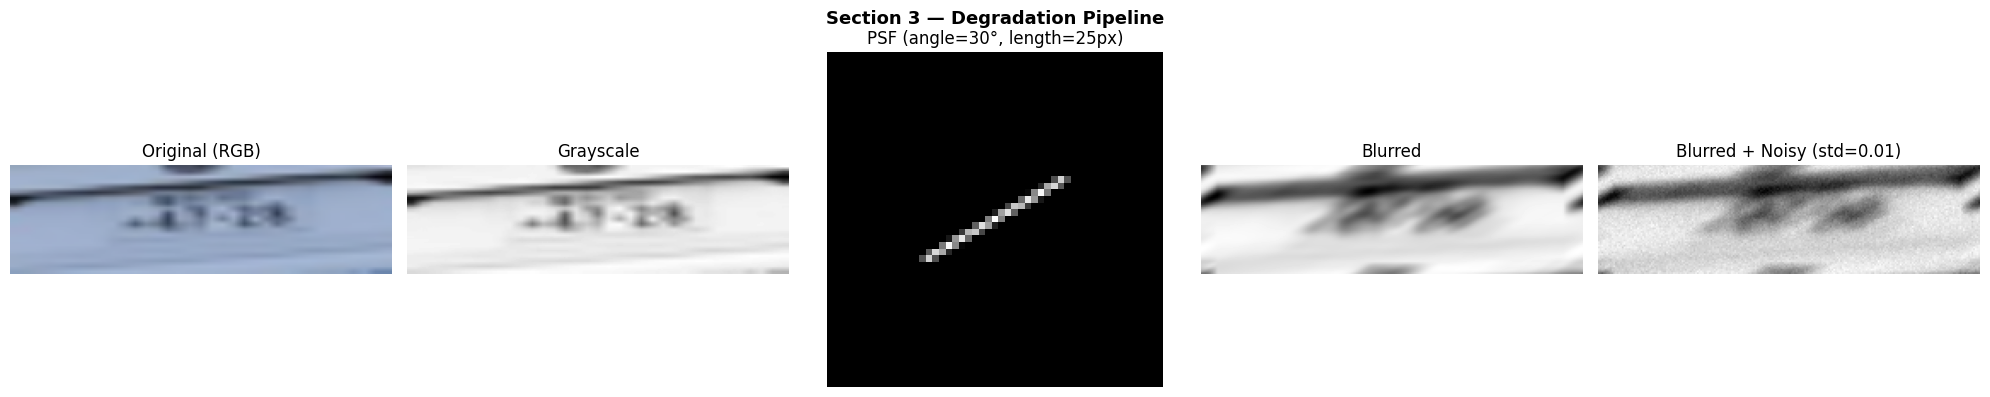

In [4]:
# ═══════════════════════════════════════
# SECTION 3 — SYNTHETIC BLUR GENERATION
# ═══════════════════════════════════════

def motion_psf(size, length, angle):
    psf = np.zeros((size, size))
    center = size // 2
    cv2.line(psf, (center - length//2, center), (center + length//2, center), 1, 1)
    M = cv2.getRotationMatrix2D((center, center), angle, 1)
    psf = cv2.warpAffine(psf, M, (size, size))
    return psf / psf.sum()

def apply_motion_blur_fft(image, psf):
    h, w = image.shape
    kh, kw = psf.shape
    psf_padded = np.zeros((h, w), dtype=np.float32)
    psf_padded[:kh, :kw] = psf
    psf_padded = np.roll(psf_padded, -kh//2, axis=0)
    psf_padded = np.roll(psf_padded, -kw//2, axis=1)
    G = np.fft.fft2(image)
    H = np.fft.fft2(psf_padded)
    return np.clip(np.abs(np.fft.ifft2(G * H)), 0, 1)

def add_noise(image, std=0.01):
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    return np.clip(image + noise, 0, 1)

TRUE_ANGLE  = 30
TRUE_LENGTH = 25
NOISE_STD   = 0.01

psf          = motion_psf(51, TRUE_LENGTH, TRUE_ANGLE)
sample       = cv2.cvtColor(train_crops[0], cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
sample_blur  = apply_motion_blur_fft(sample, psf)
sample_noisy = add_noise(sample_blur, NOISE_STD)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Section 3 — Degradation Pipeline', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(train_crops[0], cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (RGB)'); axes[0].axis('off')
axes[1].imshow(sample, cmap='gray')
axes[1].set_title('Grayscale'); axes[1].axis('off')
axes[2].imshow(psf, cmap='gray')
axes[2].set_title(f'PSF (angle={TRUE_ANGLE}°, length={TRUE_LENGTH}px)'); axes[2].axis('off')
axes[3].imshow(sample_blur, cmap='gray')
axes[3].set_title('Blurred'); axes[3].axis('off')
axes[4].imshow(sample_noisy, cmap='gray')
axes[4].set_title(f'Blurred + Noisy (std={NOISE_STD})'); axes[4].axis('off')
plt.tight_layout()
plt.show()

## Section 4 — FFT Magnitude Analysis

Motion blur creates **dark stripes** in the FFT magnitude spectrum,
perpendicular to the blur direction. This is the blur's frequency-domain fingerprint.

We use a **radial scan** to find the direction of minimum energy in the spectrum,
then correct by 90° to recover the estimated blur angle.  
This demonstrates the frequency domain analysis required by the project.

True angle:  30°    | FFT estimated: 33.0°
True length: 25px  | FFT estimated: 32px


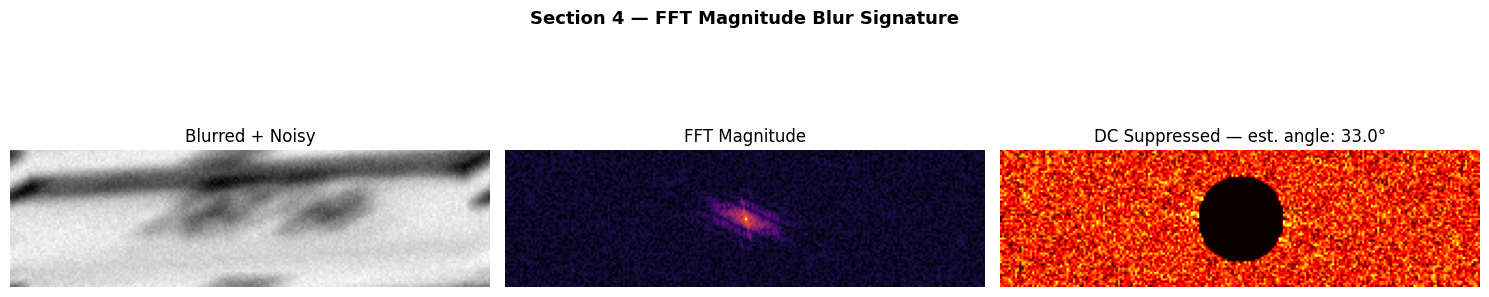

In [5]:
# ═══════════════════════════════════════
# SECTION 4 — FFT MAGNITUDE ANALYSIS
# ═══════════════════════════════════════

def estimate_blur_fft(image, length_range=(5, 40)):
    F = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log(1 + np.abs(F))
    magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
    h, w = magnitude.shape
    cx, cy = w//2, h//2
    mask = magnitude.copy()
    cv2.circle(mask, (cx, cy), 20, 0, -1)

    best_angle, min_energy = 0, float('inf')
    for angle_deg in range(0, 180, 1):
        angle_rad = np.deg2rad(angle_deg)
        energies = []
        for r in range(1, min(h, w)//2):
            x = int(cx + r * np.cos(angle_rad))
            y = int(cy + r * np.sin(angle_rad))
            if 0 <= x < w and 0 <= y < h:
                energies.append(mask[y, x])
        if energies:
            energy = np.mean(energies)
            if energy < min_energy:
                min_energy = energy
                best_angle = angle_deg

    estimated_angle = (best_angle + 90) % 180

    blur_rad = np.deg2rad(best_angle)
    profile = []
    for r in range(0, min(h, w)//2):
        x = int(cx + r * np.cos(blur_rad))
        y = int(cy + r * np.sin(blur_rad))
        if 0 <= x < w and 0 <= y < h:
            profile.append(magnitude[y, x])

    profile = np.array(profile)
    estimated_length = 15
    if len(profile) > 5:
        profile = profile / profile.max()
        for i in range(2, len(profile)):
            if profile[i] < 0.3 and profile[i-1] >= 0.3:
                estimated_length = int(np.clip(min(h, w) // max(i, 1) * 2,
                                               length_range[0], length_range[1]))
                break

    return estimated_angle, estimated_length, magnitude, mask

est_angle_fft, est_length_fft, magnitude, mask = estimate_blur_fft(sample_noisy)

print(f'True angle:  {TRUE_ANGLE}°    | FFT estimated: {est_angle_fft:.1f}°')
print(f'True length: {TRUE_LENGTH}px  | FFT estimated: {est_length_fft}px')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Section 4 — FFT Magnitude Blur Signature', fontsize=13, fontweight='bold')
axes[0].imshow(sample_noisy, cmap='gray'); axes[0].set_title('Blurred + Noisy'); axes[0].axis('off')
axes[1].imshow(magnitude, cmap='inferno'); axes[1].set_title('FFT Magnitude'); axes[1].axis('off')
axes[2].imshow(mask, cmap='hot'); axes[2].set_title(f'DC Suppressed — est. angle: {est_angle_fft:.1f}°'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## Section 5 — CNN-based PSF Estimation

A small CNN learns to predict blur **angle** and **length** directly from the
FFT magnitude of the blurred image. This makes the pipeline fully **blind** —
no ground truth PSF is needed at inference time.

**Architecture:** 4 conv layers → AdaptiveAvgPool → 2 FC layers → 3 outputs

**Outputs:** `[cos(2θ), sin(2θ), normalized_length]`

We encode angle as cos/sin to handle the **0°=180° ambiguity** —
a 0° blur and 180° blur produce identical images.

**Training:** 4000 samples with random blur parameters applied to real plate crops.

Building dataset...
Training CNN...
Epoch 01 | train=0.1082 | val=0.0616
Epoch 02 | train=0.0398 | val=0.0328
Epoch 03 | train=0.0281 | val=0.0382
Epoch 04 | train=0.0245 | val=0.0389
Epoch 05 | train=0.0229 | val=0.0205
Epoch 06 | train=0.0179 | val=0.0127
Epoch 07 | train=0.0172 | val=0.0113
Epoch 08 | train=0.0157 | val=0.0122
Epoch 09 | train=0.0151 | val=0.0199
Epoch 10 | train=0.0141 | val=0.0183
Epoch 11 | train=0.0139 | val=0.0117
Epoch 12 | train=0.0128 | val=0.0085
Epoch 13 | train=0.0121 | val=0.0096
Epoch 14 | train=0.0123 | val=0.0090
Epoch 15 | train=0.0114 | val=0.0092
Epoch 16 | train=0.0117 | val=0.0088
Epoch 17 | train=0.0111 | val=0.0090
Epoch 18 | train=0.0110 | val=0.0077
Epoch 19 | train=0.0109 | val=0.0073
Epoch 20 | train=0.0110 | val=0.0074
Epoch 21 | train=0.0107 | val=0.0079
Epoch 22 | train=0.0100 | val=0.0072
Epoch 23 | train=0.0101 | val=0.0076
Epoch 24 | train=0.0104 | val=0.0073
Epoch 25 | train=0.0100 | val=0.0071
CNN training complete ✅


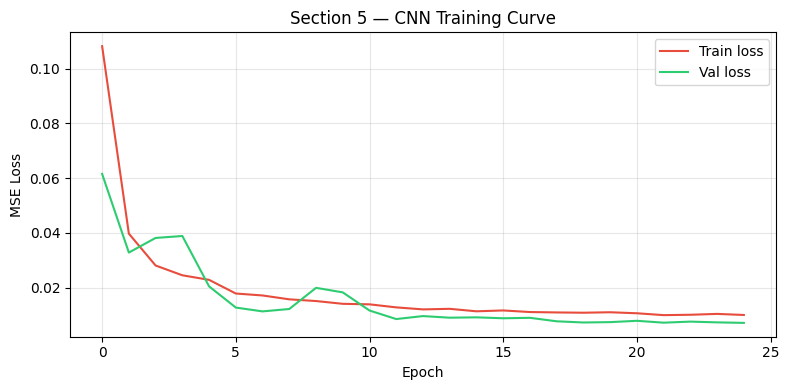


True:  angle=30°  length=25px
CNN:   angle=25.9°  length=25px


In [6]:
# ═══════════════════════════════════════
# SECTION 5 — CNN-BASED PSF ESTIMATION
# ═══════════════════════════════════════

def compute_fft_features(gray_float, out_size=64):
    F = np.fft.fftshift(np.fft.fft2(gray_float))
    magnitude = np.log(1 + np.abs(F))
    magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)
    magnitude = cv2.resize(magnitude, (out_size, out_size))
    hp = magnitude - cv2.GaussianBlur(magnitude, (0, 0), 3.0)
    hp = (hp - hp.min()) / (hp.max() - hp.min() + 1e-8)
    return np.stack([magnitude, hp], axis=0).astype(np.float32)

class BlurDataset(Dataset):
    def __init__(self, crops, n_samples=4000, min_angle=0, max_angle=180,
                 min_length=5, max_length=40):
        self.min_length = min_length
        self.max_length = max_length
        self.samples = []
        for _ in range(n_samples):
            crop   = random.choice(crops)
            g      = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
            angle  = random.uniform(min_angle, max_angle)
            length = random.randint(min_length, max_length)
            p      = motion_psf(51, length, angle)
            b      = apply_motion_blur_fft(g, p)
            bn     = add_noise(b, std=random.uniform(0.005, 0.02))
            self.samples.append((compute_fft_features(bn), angle, length))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fft, angle, length = self.samples[idx]
        target = np.array([
            np.cos(2 * np.deg2rad(angle)),
            np.sin(2 * np.deg2rad(angle)),
            (length - self.min_length) / (self.max_length - self.min_length)
        ], dtype=np.float32)
        return torch.tensor(fft), torch.tensor(target)

class BlurEstimatorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.regressor(self.features(x))

def decode_output(pred):
    pred   = pred.detach().cpu().numpy()
    angle  = 0.5 * np.rad2deg(np.arctan2(pred[:, 1], pred[:, 0])) % 180
    length = int(np.clip(np.round(5 + pred[:, 2][0] * 35), 5, 40))
    return float(angle[0]), length

def estimate_psf_cnn(image_gray_float):
    model_cnn.eval()
    x = torch.tensor(compute_fft_features(image_gray_float)[None]).to(DEVICE)
    with torch.no_grad():
        pred = model_cnn(x)
    return decode_output(pred)

# Training
print('Building dataset...')
train_ds     = BlurDataset(train_crops, n_samples=4000)
val_ds       = BlurDataset(val_crops,   n_samples=500)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

model_cnn = BlurEstimatorCNN().to(DEVICE)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses = [], []
print('Training CNN...')
for epoch in range(1, 26):
    model_cnn.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = F.mse_loss(model_cnn(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    model_cnn.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            val_loss += F.mse_loss(model_cnn(x), y).item() * x.size(0)
    scheduler.step()
    tl = total_loss / len(train_ds)
    vl = val_loss   / len(val_ds)
    train_losses.append(tl)
    val_losses.append(vl)
    print(f'Epoch {epoch:02d} | train={tl:.4f} | val={vl:.4f}')

print('CNN training complete \u2705')

# Training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss', color='#e74c3c')
ax.plot(val_losses,   label='Val loss',   color='#2ecc71')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Section 5 — CNN Training Curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test on sample
est_angle_cnn, est_length_cnn = estimate_psf_cnn(sample_noisy)
print(f'\nTrue:  angle={TRUE_ANGLE}\u00b0  length={TRUE_LENGTH}px')
print(f'CNN:   angle={est_angle_cnn:.1f}\u00b0  length={est_length_cnn}px')

## Section 6 — Wiener Filter

The Wiener filter is the **optimal linear deblurring filter** under Gaussian noise.
It minimizes mean squared error between the estimated and true image.

**Frequency domain formula:**

> **F̂ = (H\* / (|H|² + K)) · G**

| Symbol | Meaning |
|---|---|
| G | FFT of blurred noisy image |
| H | FFT of the PSF |
| H\* | Complex conjugate of H |
| K | Regularization — noise/signal ratio |
| F̂ | Estimated FFT of original image |

**K tradeoff:** small K → sharp but noisy · large K → smooth but blurry

In [7]:
# ═══════════════════════════════════════
# SECTION 6 — WIENER FILTER
# ═══════════════════════════════════════

def wiener_deblur(img, psf, K=0.01):
    h, w = img.shape
    psf_padded = np.zeros((h, w), dtype=np.float32)
    kh, kw = psf.shape
    psf_padded[:kh, :kw] = psf
    psf_padded = np.roll(psf_padded, -kh//2, axis=0)
    psf_padded = np.roll(psf_padded, -kw//2, axis=1)
    G     = np.fft.fft2(img)
    H     = np.fft.fft2(psf_padded)
    F_hat = (np.conj(H) / (np.abs(H)**2 + K)) * G
    return np.clip(np.abs(np.fft.ifft2(F_hat)), 0, 1)

print('Wiener filter ready \u2705')

Wiener filter ready ✅


## Section 7 — K Parameter Sweep

We sweep K across 6 values to find the optimal regularization.
The curve shows the noise/sharpness tradeoff — **optimal K = 0.01**.

K=0.0001  →  PSNR: 17.25 dB
K=0.0010  →  PSNR: 22.20 dB
K=0.0050  →  PSNR: 24.85 dB
K=0.0100  →  PSNR: 25.30 dB
K=0.0200  →  PSNR: 25.15 dB
K=0.0500  →  PSNR: 23.80 dB

Optimal K: 0.01


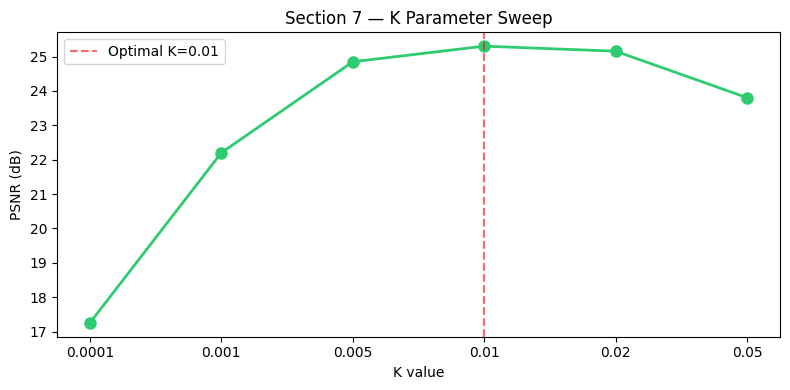

In [8]:
# ═══════════════════════════════════════
# SECTION 7 — K PARAMETER SWEEP
# ═══════════════════════════════════════

k_values = [1e-4, 1e-3, 0.005, 0.01, 0.02, 0.05]
k_psnrs  = []

cnn_psf  = motion_psf(51, est_length_cnn, est_angle_cnn)
denoised = cv2.fastNlMeansDenoising(
    (sample_noisy * 255).astype(np.uint8), h=3
).astype(np.float32) / 255.0

for k in k_values:
    r = wiener_deblur(denoised, cnn_psf, K=k)
    p = peak_signal_noise_ratio(sample, r, data_range=1.0)
    k_psnrs.append(p)
    print(f'K={k:.4f}  →  PSNR: {p:.2f} dB')

best_k = k_values[k_psnrs.index(max(k_psnrs))]
print(f'\nOptimal K: {best_k}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(k_values)), k_psnrs, 'o-', color='#2ecc71', linewidth=2, markersize=8)
ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([str(k) for k in k_values])
ax.set_xlabel('K value'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Section 7 — K Parameter Sweep')
ax.axvline(x=k_psnrs.index(max(k_psnrs)), color='red', linestyle='--',
           alpha=0.6, label=f'Optimal K={best_k}')
ax.legend()
plt.tight_layout()
plt.show()

## Section 8 — Evaluation (Ground Truth PSF — Upper Bound)

We first evaluate using the **known ground truth PSF**.
This represents the **upper bound** — the best possible result with perfect estimation.  
Each validation image is independently blurred, noised, denoised, and restored.

Evaluating with ground truth PSF (upper bound)...


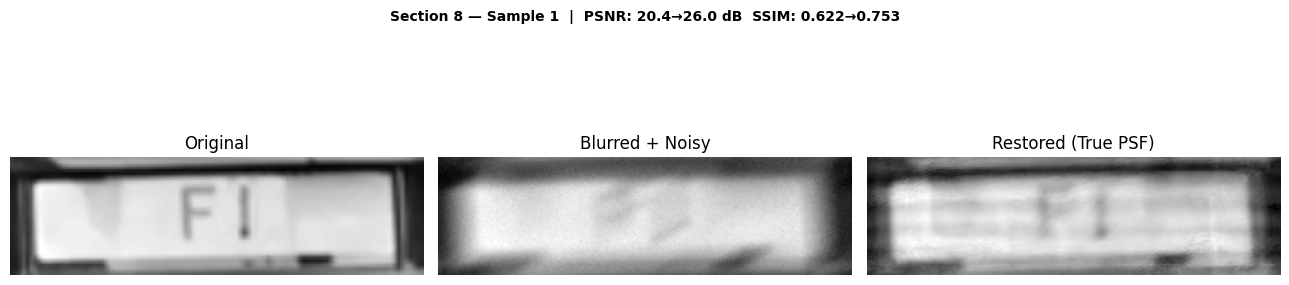

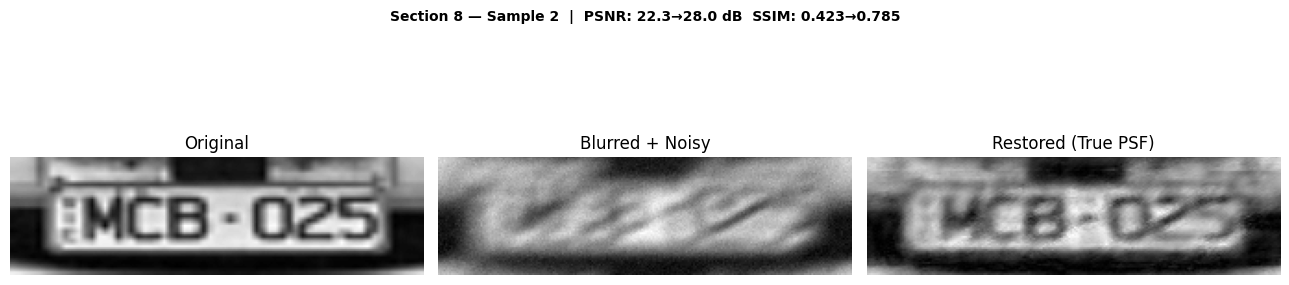

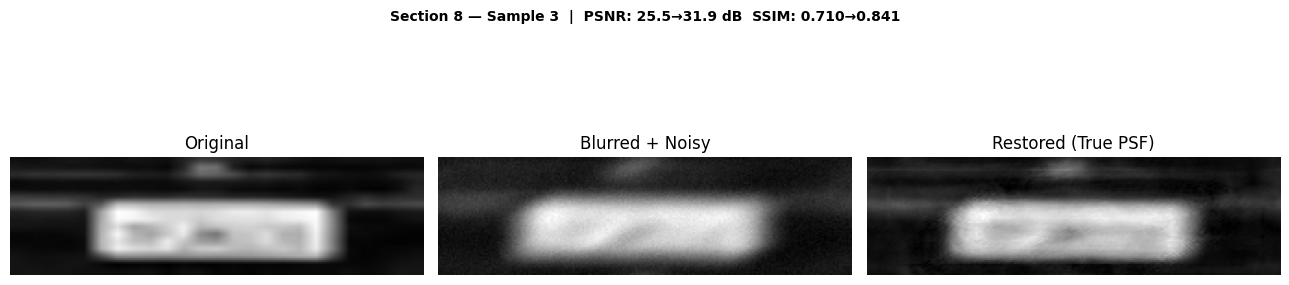


SECTION 8 — GROUND TRUTH PSF (95 images)
Metric             Blurred   Restored       Gain
-------------------------------------------------------
PSNR (dB)            17.77      23.31      +5.54
SSIM                 0.401      0.727     +0.326


In [9]:
# ═══════════════════════════════════════
# SECTION 8 — EVALUATION (GROUND TRUTH PSF)
# ═══════════════════════════════════════

def evaluate_dataset(crops, psf, K=0.01, noise_std=0.01, show_n=3):
    results = []
    for i, crop in enumerate(crops):
        g  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        b  = apply_motion_blur_fft(g, psf)
        bn = add_noise(b, noise_std)
        bd = cv2.fastNlMeansDenoising((bn*255).astype(np.uint8), h=3).astype(np.float32) / 255.0
        restored = wiener_deblur(bd, psf, K=K)
        psnr_b = peak_signal_noise_ratio(g, bn,       data_range=1.0)
        psnr_r = peak_signal_noise_ratio(g, restored, data_range=1.0)
        ssim_b = structural_similarity(g, bn,       data_range=1.0)
        ssim_r = structural_similarity(g, restored, data_range=1.0)
        results.append({'psnr_blurred': psnr_b, 'psnr_restored': psnr_r,
                        'ssim_blurred': ssim_b, 'ssim_restored': ssim_r})
        if i < show_n:
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            fig.suptitle(f'Section 8 — Sample {i+1}  |  '
                         f'PSNR: {psnr_b:.1f}\u2192{psnr_r:.1f} dB  '
                         f'SSIM: {ssim_b:.3f}\u2192{ssim_r:.3f}',
                         fontsize=10, fontweight='bold')
            axes[0].imshow(g,        cmap='gray'); axes[0].set_title('Original');           axes[0].axis('off')
            axes[1].imshow(bn,       cmap='gray'); axes[1].set_title('Blurred + Noisy');    axes[1].axis('off')
            axes[2].imshow(restored, cmap='gray'); axes[2].set_title('Restored (True PSF)'); axes[2].axis('off')
            plt.tight_layout(); plt.show()
    return results

print('Evaluating with ground truth PSF (upper bound)...')
gt_results    = evaluate_dataset(val_crops, psf, K=0.01)
avg_psnr_b_gt = np.mean([r['psnr_blurred']  for r in gt_results])
avg_psnr_r_gt = np.mean([r['psnr_restored'] for r in gt_results])
avg_ssim_b_gt = np.mean([r['ssim_blurred']  for r in gt_results])
avg_ssim_r_gt = np.mean([r['ssim_restored'] for r in gt_results])

print(f"\n{'='*55}")
print(f"SECTION 8 — GROUND TRUTH PSF ({len(gt_results)} images)")
print(f"{'='*55}")
print(f"{'Metric':<15} {'Blurred':>10} {'Restored':>10} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'PSNR (dB)':<15} {avg_psnr_b_gt:>10.2f} {avg_psnr_r_gt:>10.2f} {avg_psnr_r_gt-avg_psnr_b_gt:>+10.2f}")
print(f"{'SSIM':<15} {avg_ssim_b_gt:>10.3f} {avg_ssim_r_gt:>10.3f} {avg_ssim_r_gt-avg_ssim_b_gt:>+10.3f}")

## Section 9 — Evaluation (CNN Blind Pipeline)

We now evaluate the **fully blind pipeline** — the CNN estimates the PSF
from the blurred image alone, with no knowledge of the true parameters.

The gap between Section 8 and Section 9 results represents the **cost of blind estimation**.

Evaluating with CNN-estimated PSF (blind)...


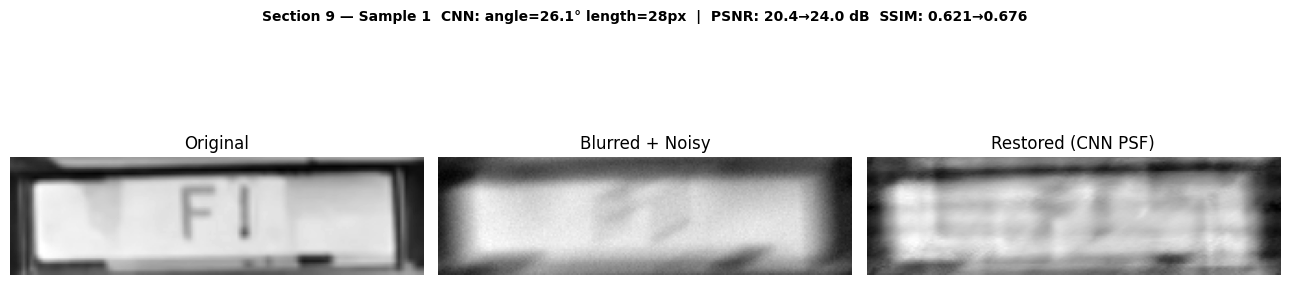

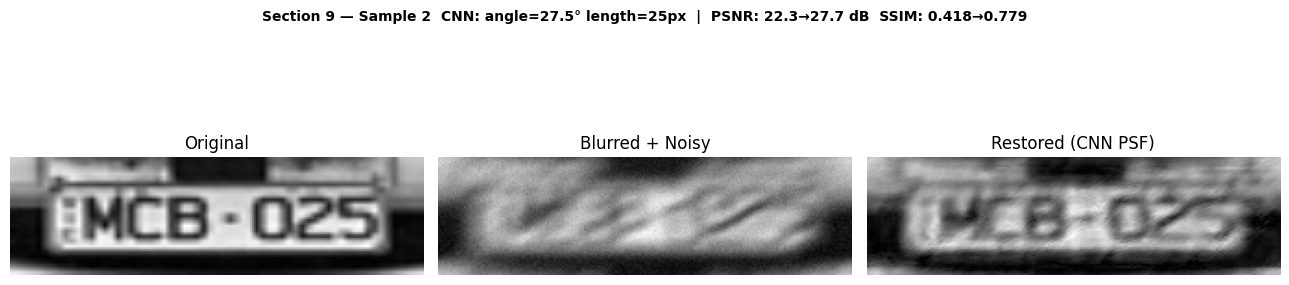

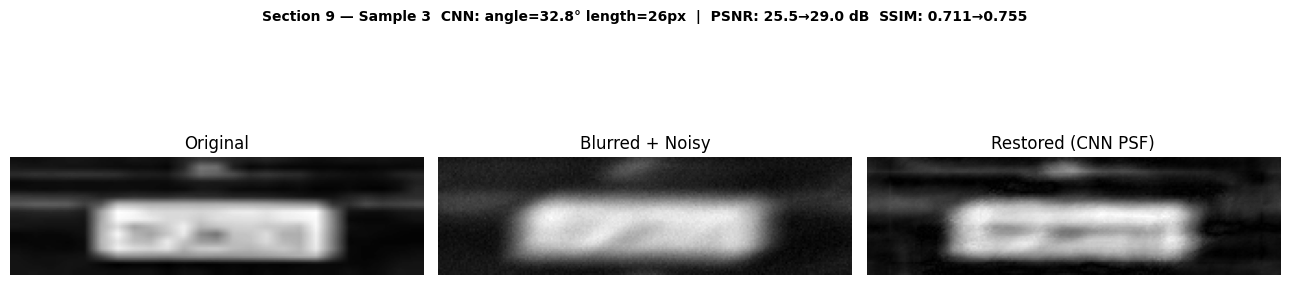


SECTION 9 — CNN BLIND PIPELINE (95 images)
Metric             Blurred   Restored       Gain
-------------------------------------------------------
PSNR (dB)            17.77      21.93      +4.17
SSIM                 0.402      0.660     +0.258


In [10]:
# ═══════════════════════════════════════
# SECTION 9 — EVALUATION (CNN BLIND)
# ═══════════════════════════════════════

def evaluate_with_cnn(crops, K=0.01, noise_std=0.01, show_n=3):
    results = []
    for i, crop in enumerate(crops):
        g  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        b  = apply_motion_blur_fft(g, psf)
        bn = add_noise(b, noise_std)
        est_a, est_l = estimate_psf_cnn(bn)
        est_p = motion_psf(51, est_l, est_a)
        bd = cv2.fastNlMeansDenoising((bn*255).astype(np.uint8), h=3).astype(np.float32) / 255.0
        restored = wiener_deblur(bd, est_p, K=K)
        psnr_b = peak_signal_noise_ratio(g, bn,       data_range=1.0)
        psnr_r = peak_signal_noise_ratio(g, restored, data_range=1.0)
        ssim_b = structural_similarity(g, bn,       data_range=1.0)
        ssim_r = structural_similarity(g, restored, data_range=1.0)
        results.append({'psnr_blurred': psnr_b, 'psnr_restored': psnr_r,
                        'ssim_blurred': ssim_b, 'ssim_restored': ssim_r,
                        'est_angle': est_a, 'est_length': est_l})
        if i < show_n:
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            fig.suptitle(f'Section 9 — Sample {i+1}  CNN: angle={est_a:.1f}\u00b0 length={est_l}px  |  '
                         f'PSNR: {psnr_b:.1f}\u2192{psnr_r:.1f} dB  '
                         f'SSIM: {ssim_b:.3f}\u2192{ssim_r:.3f}',
                         fontsize=10, fontweight='bold')
            axes[0].imshow(g,        cmap='gray'); axes[0].set_title('Original');           axes[0].axis('off')
            axes[1].imshow(bn,       cmap='gray'); axes[1].set_title('Blurred + Noisy');    axes[1].axis('off')
            axes[2].imshow(restored, cmap='gray'); axes[2].set_title('Restored (CNN PSF)'); axes[2].axis('off')
            plt.tight_layout(); plt.show()
    return results

print('Evaluating with CNN-estimated PSF (blind)...')
cnn_results    = evaluate_with_cnn(val_crops, K=0.01)
avg_psnr_b_cnn = np.mean([r['psnr_blurred']  for r in cnn_results])
avg_psnr_r_cnn = np.mean([r['psnr_restored'] for r in cnn_results])
avg_ssim_b_cnn = np.mean([r['ssim_blurred']  for r in cnn_results])
avg_ssim_r_cnn = np.mean([r['ssim_restored'] for r in cnn_results])

print(f"\n{'='*55}")
print(f"SECTION 9 — CNN BLIND PIPELINE ({len(cnn_results)} images)")
print(f"{'='*55}")
print(f"{'Metric':<15} {'Blurred':>10} {'Restored':>10} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'PSNR (dB)':<15} {avg_psnr_b_cnn:>10.2f} {avg_psnr_r_cnn:>10.2f} {avg_psnr_r_cnn-avg_psnr_b_cnn:>+10.2f}")
print(f"{'SSIM':<15} {avg_ssim_b_cnn:>10.3f} {avg_ssim_r_cnn:>10.3f} {avg_ssim_r_cnn-avg_ssim_b_cnn:>+10.3f}")

## Section 10 — Results Visualization

PSNR and SSIM plotted per image across the validation set.  
Red = blurred · Green = restored · Dashed lines = dataset averages.

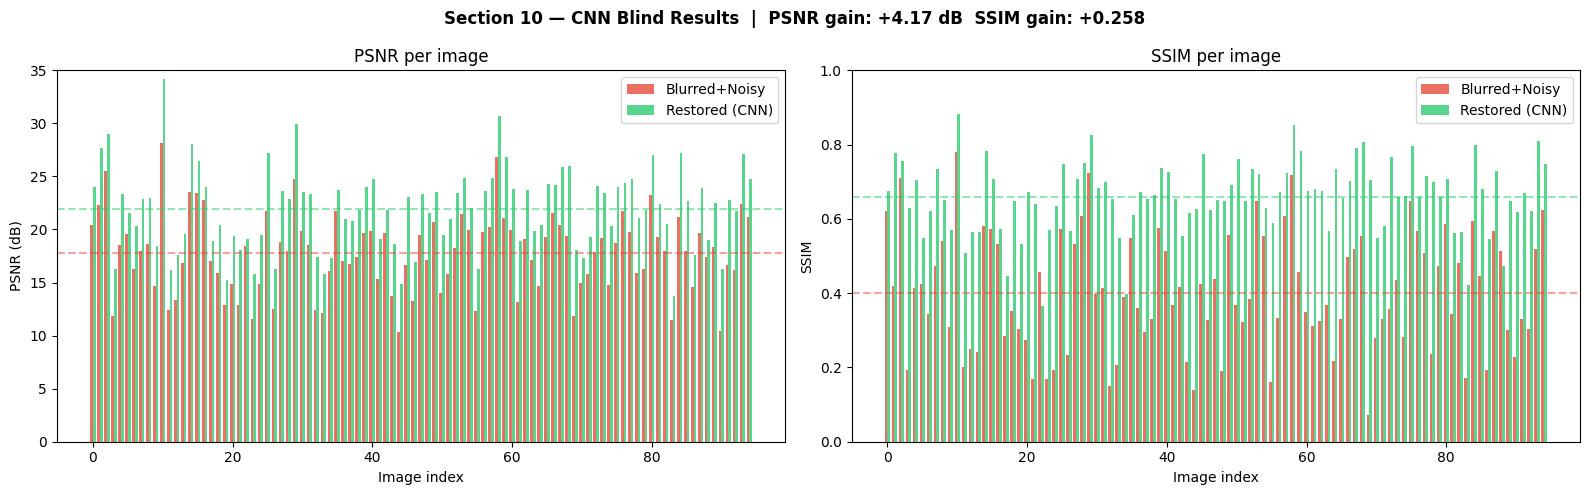

In [11]:
# ═══════════════════════════════════════
# SECTION 10 — RESULTS VISUALIZATION
# ═══════════════════════════════════════

psnr_b_vals = [r['psnr_blurred']  for r in cnn_results]
psnr_r_vals = [r['psnr_restored'] for r in cnn_results]
ssim_b_vals = [r['ssim_blurred']  for r in cnn_results]
ssim_r_vals = [r['ssim_restored'] for r in cnn_results]
x = np.arange(len(cnn_results))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f'Section 10 — CNN Blind Results  |  '
    f'PSNR gain: +{avg_psnr_r_cnn-avg_psnr_b_cnn:.2f} dB  '
    f'SSIM gain: +{avg_ssim_r_cnn-avg_ssim_b_cnn:.3f}',
    fontsize=12, fontweight='bold'
)
axes[0].bar(x-0.2, psnr_b_vals, 0.4, label='Blurred+Noisy', color='#e74c3c', alpha=0.8)
axes[0].bar(x+0.2, psnr_r_vals, 0.4, label='Restored (CNN)', color='#2ecc71', alpha=0.8)
axes[0].axhline(y=avg_psnr_b_cnn, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0].axhline(y=avg_psnr_r_cnn, color='#2ecc71', linestyle='--', alpha=0.5)
axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('PSNR per image')
axes[0].set_xlabel('Image index'); axes[0].legend(); axes[0].set_ylim(0, 35)

axes[1].bar(x-0.2, ssim_b_vals, 0.4, label='Blurred+Noisy', color='#e74c3c', alpha=0.8)
axes[1].bar(x+0.2, ssim_r_vals, 0.4, label='Restored (CNN)', color='#2ecc71', alpha=0.8)
axes[1].axhline(y=avg_ssim_b_cnn, color='#e74c3c', linestyle='--', alpha=0.5)
axes[1].axhline(y=avg_ssim_r_cnn, color='#2ecc71', linestyle='--', alpha=0.5)
axes[1].set_ylabel('SSIM'); axes[1].set_title('SSIM per image')
axes[1].set_xlabel('Image index'); axes[1].legend(); axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Section 11 — Method Comparison

We compare four approaches to understand what each component contributes:

| Method | Noise model | What it tests |
|---|---|---|
| Naive Inverse Filter | None | Baseline — no regularization |
| Lucy-Richardson | Poisson | Different noise assumption |
| Wiener — CNN PSF | Gaussian | Our blind method |
| Wiener — True PSF | Gaussian | Upper bound |

The gap between **Naive Inverse** and **Wiener** shows the value of K regularization.  
The gap between **Lucy-Richardson** and **Wiener** shows the importance of matching the noise model.

Comparing methods on 5 validation images...

SECTION 11 — METHOD COMPARISON (5 images)
Method                                Avg PSNR Note
------------------------------------------------------------
Naive Inverse Filter                      6.80 dB  no regularization
Lucy-Richardson                          21.41 dB  Poisson noise model
Wiener — CNN PSF (blind)                 24.13 dB  Gaussian noise model
Wiener — True PSF (upper bound)          25.37 dB  perfect estimation

Naive filter vs Wiener (CNN): +17.33 dB — value of K regularization
Lucy-Richardson vs Wiener:    +2.72 dB — value of correct noise model


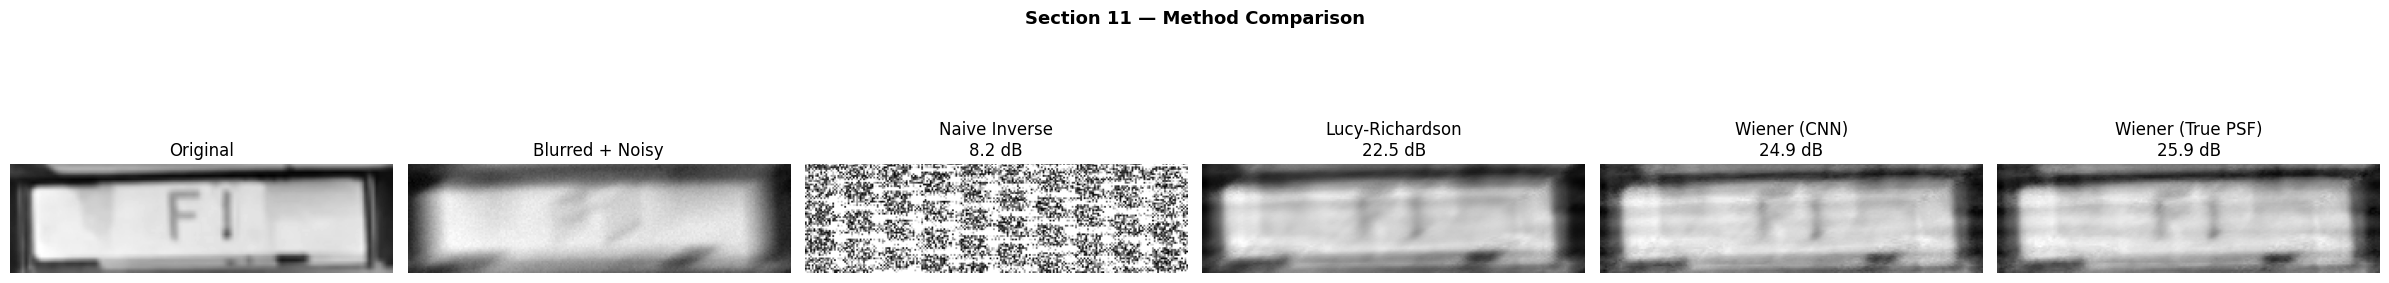

In [12]:
# ═══════════════════════════════════════
# SECTION 11 — METHOD COMPARISON
# ═══════════════════════════════════════

def lucy_richardson(img, psf, iterations=30):
    psf_flip = np.flip(psf)
    estimate = img.copy()
    for _ in range(iterations):
        conv = convolve2d(estimate, psf, mode='same', boundary='wrap')
        conv = np.where(conv == 0, 1e-6, conv)
        ratio = img / conv
        estimate = estimate * convolve2d(ratio, psf_flip, mode='same', boundary='wrap')
        estimate = np.clip(estimate, 0, 1)
    return estimate

def naive_inverse_filter(img, psf, epsilon=1e-3):
    h, w = img.shape
    psf_padded = np.zeros((h, w), dtype=np.float32)
    kh, kw = psf.shape
    psf_padded[:kh, :kw] = psf
    psf_padded = np.roll(psf_padded, -kh//2, axis=0)
    psf_padded = np.roll(psf_padded, -kw//2, axis=1)
    G = np.fft.fft2(img)
    H = np.fft.fft2(psf_padded)
    H_safe = np.where(np.abs(H) < epsilon, epsilon, H)
    return np.clip(np.abs(np.fft.ifft2(G / H_safe)), 0, 1)

print("Comparing methods on 5 validation images...")
naive_psnrs, lr_psnrs, wiener_cnn_psnrs, wiener_gt_psnrs = [], [], [], []

for crop in val_crops[:5]:
    g  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    b  = apply_motion_blur_fft(g, psf)
    bn = add_noise(b, NOISE_STD)
    bd = cv2.fastNlMeansDenoising((bn*255).astype(np.uint8), h=3).astype(np.float32) / 255.0

    est_a, est_l = estimate_psf_cnn(bn)
    est_p = motion_psf(51, est_l, est_a)

    r_naive      = naive_inverse_filter(bd, est_p)
    r_lr         = lucy_richardson(bn, est_p, iterations=30)
    r_wiener_cnn = wiener_deblur(bd, est_p, K=0.01)
    r_wiener_gt  = wiener_deblur(bd, psf,   K=0.01)

    naive_psnrs.append(peak_signal_noise_ratio(g, r_naive,      data_range=1.0))
    lr_psnrs.append(peak_signal_noise_ratio(g, r_lr,            data_range=1.0))
    wiener_cnn_psnrs.append(peak_signal_noise_ratio(g, r_wiener_cnn, data_range=1.0))
    wiener_gt_psnrs.append(peak_signal_noise_ratio(g, r_wiener_gt,  data_range=1.0))

avg_naive      = np.mean(naive_psnrs)
avg_lr         = np.mean(lr_psnrs)
avg_wiener_cnn = np.mean(wiener_cnn_psnrs)
avg_wiener_gt  = np.mean(wiener_gt_psnrs)

print(f"\n{'='*60}")
print(f"SECTION 11 — METHOD COMPARISON (5 images)")
print(f"{'='*60}")
print(f"{'Method':<35} {'Avg PSNR':>10} {'Note'}")
print(f"{'-'*60}")
print(f"{'Naive Inverse Filter':<35} {avg_naive:>10.2f} dB  no regularization")
print(f"{'Lucy-Richardson':<35} {avg_lr:>10.2f} dB  Poisson noise model")
print(f"{'Wiener — CNN PSF (blind)':<35} {avg_wiener_cnn:>10.2f} dB  Gaussian noise model")
print(f"{'Wiener — True PSF (upper bound)':<35} {avg_wiener_gt:>10.2f} dB  perfect estimation")
print(f"{'='*60}")
print(f"\nNaive filter vs Wiener (CNN): {avg_wiener_cnn - avg_naive:+.2f} dB — value of K regularization")
print(f"Lucy-Richardson vs Wiener:    {avg_wiener_cnn - avg_lr:+.2f} dB — value of correct noise model")

# Visual comparison on one sample
g  = cv2.cvtColor(val_crops[0], cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
b  = apply_motion_blur_fft(g, psf)
bn = add_noise(b, NOISE_STD)
bd = cv2.fastNlMeansDenoising((bn*255).astype(np.uint8), h=3).astype(np.float32) / 255.0
est_a, est_l = estimate_psf_cnn(bn)
est_p = motion_psf(51, est_l, est_a)

r_naive      = naive_inverse_filter(bd, est_p)
r_lr         = lucy_richardson(bd, est_p, iterations=30)
r_wiener_cnn = wiener_deblur(bd, est_p, K=0.01)
r_wiener_gt_vis = wiener_deblur(bd, psf, K=0.01)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
fig.suptitle('Section 11 — Method Comparison', fontsize=13, fontweight='bold')

axes[0].imshow(g,               cmap='gray'); axes[0].set_title('Original');                                                                          axes[0].axis('off')
axes[1].imshow(bn,              cmap='gray'); axes[1].set_title('Blurred + Noisy');                                                                    axes[1].axis('off')
axes[2].imshow(r_naive,         cmap='gray'); axes[2].set_title(f'Naive Inverse\n{peak_signal_noise_ratio(g, r_naive, data_range=1.0):.1f} dB');       axes[2].axis('off')
axes[3].imshow(r_lr,            cmap='gray'); axes[3].set_title(f'Lucy-Richardson\n{peak_signal_noise_ratio(g, r_lr, data_range=1.0):.1f} dB');        axes[3].axis('off')
axes[4].imshow(r_wiener_cnn,    cmap='gray'); axes[4].set_title(f'Wiener (CNN)\n{peak_signal_noise_ratio(g, r_wiener_cnn, data_range=1.0):.1f} dB');   axes[4].axis('off')
axes[5].imshow(r_wiener_gt_vis, cmap='gray'); axes[5].set_title(f'Wiener (True PSF)\n{peak_signal_noise_ratio(g, r_wiener_gt_vis, data_range=1.0):.1f} dB'); axes[5].axis('off')

plt.tight_layout()
plt.show()


SECTION 12 — FINAL RESULTS SUMMARY (95 validation images)
Method                                   PSNR (dB)           SSIM  PSNR Gain
------------------------------------------------------------------------
Blurred + Noisy                      17.77±3.70  0.402±0.157          —
Naive Inverse Filter                  6.80                 —     -10.96
Lucy-Richardson                      21.41                 —      +3.64
Wiener — CNN PSF (blind)             21.93±3.82  0.660±0.097      +4.17
Wiener — True PSF (upper bound)      23.31±3.84  0.727±0.069      +5.54

Key findings:
  Naive filter vs Wiener (CNN):  +17.33 dB — value of K regularization
  Lucy-Richardson vs Wiener:     +2.72 dB — value of correct noise model
  CNN PSF vs True PSF:           +1.38 dB — cost of blind estimation
  MSE reduction (CNN blind):     factor 2.6x


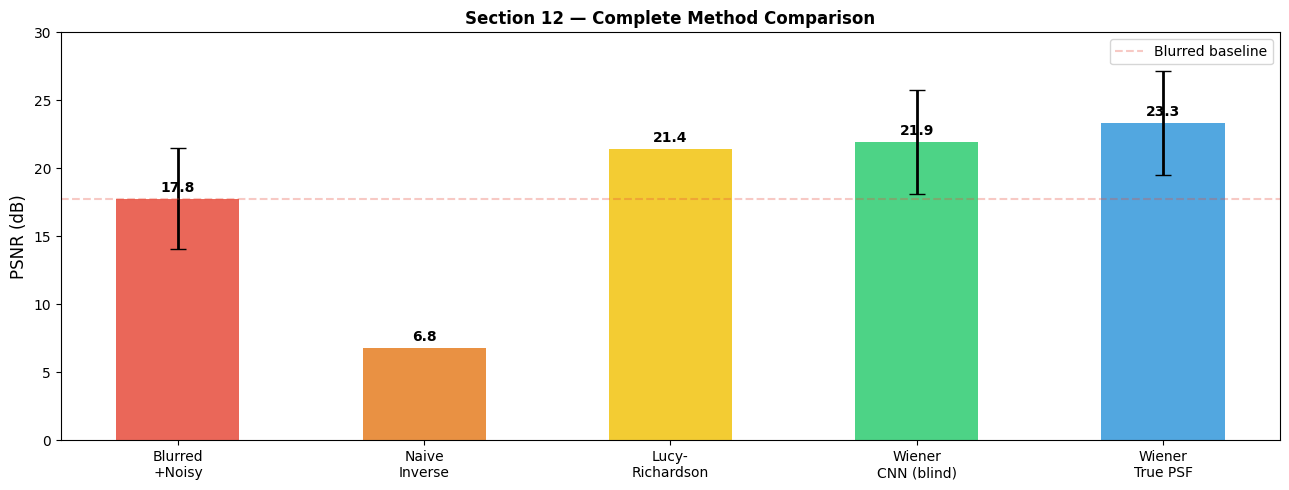

In [13]:
# ═══════════════════════════════════════
# SECTION 12 — RESULTS SUMMARY
# ═══════════════════════════════════════

psnr_std_cnn = np.std([r['psnr_restored'] for r in cnn_results])
ssim_std_cnn = np.std([r['ssim_restored'] for r in cnn_results])
psnr_std_b   = np.std([r['psnr_blurred']  for r in cnn_results])
ssim_std_b   = np.std([r['ssim_blurred']  for r in cnn_results])
psnr_std_gt  = np.std([r['psnr_restored'] for r in gt_results])
ssim_std_gt  = np.std([r['ssim_restored'] for r in gt_results])

print(f"\n{'='*72}")
print(f"SECTION 12 — FINAL RESULTS SUMMARY ({len(cnn_results)} validation images)")
print(f"{'='*72}")
print(f"{'Method':<35} {'PSNR (dB)':>14} {'SSIM':>14} {'PSNR Gain':>10}")
print(f"{'-'*72}")
print(f"{'Blurred + Noisy':<35} "
      f"{avg_psnr_b_cnn:>6.2f}±{psnr_std_b:.2f} "
      f"{avg_ssim_b_cnn:>6.3f}±{ssim_std_b:.3f} "
      f"{'—':>10}")
print(f"{'Naive Inverse Filter':<35} "
      f"{avg_naive:>6.2f}{'':>7} "
      f"{'—':>10} "
      f"{avg_naive-avg_psnr_b_cnn:>+10.2f}")
print(f"{'Lucy-Richardson':<35} "
      f"{avg_lr:>6.2f}{'':>7} "
      f"{'—':>10} "
      f"{avg_lr-avg_psnr_b_cnn:>+10.2f}")
print(f"{'Wiener — CNN PSF (blind)':<35} "
      f"{avg_psnr_r_cnn:>6.2f}±{psnr_std_cnn:.2f} "
      f"{avg_ssim_r_cnn:>6.3f}±{ssim_std_cnn:.3f} "
      f"{avg_psnr_r_cnn-avg_psnr_b_cnn:>+10.2f}")
print(f"{'Wiener — True PSF (upper bound)':<35} "
      f"{avg_psnr_r_gt:>6.2f}±{psnr_std_gt:.2f} "
      f"{avg_ssim_r_gt:>6.3f}±{ssim_std_gt:.3f} "
      f"{avg_psnr_r_gt-avg_psnr_b_gt:>+10.2f}")
print(f"{'='*72}")
print(f"\nKey findings:")
print(f"  Naive filter vs Wiener (CNN):  {avg_wiener_cnn-avg_naive:+.2f} dB — value of K regularization")
print(f"  Lucy-Richardson vs Wiener:     {avg_wiener_cnn-avg_lr:+.2f} dB — value of correct noise model")
print(f"  CNN PSF vs True PSF:           {avg_psnr_r_gt-avg_psnr_r_cnn:+.2f} dB — cost of blind estimation")
print(f"  MSE reduction (CNN blind):     factor {10**((avg_psnr_r_cnn-avg_psnr_b_cnn)/10):.1f}x")

# Final bar chart
fig, ax = plt.subplots(figsize=(13, 5))
methods = ['Blurred\n+Noisy', 'Naive\nInverse', 'Lucy-\nRichardson',
           'Wiener\nCNN (blind)', 'Wiener\nTrue PSF']
psnrs   = [avg_psnr_b_cnn, avg_naive, avg_lr, avg_psnr_r_cnn, avg_psnr_r_gt]
stds    = [psnr_std_b,      0,         0,      psnr_std_cnn,   psnr_std_gt]
colors  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

bars = ax.bar(methods, psnrs, color=colors, alpha=0.85, width=0.5)
ax.errorbar([0, 3, 4], [psnrs[0], psnrs[3], psnrs[4]],
            yerr=[stds[0], stds[3], stds[4]],
            fmt='none', color='black', capsize=6, linewidth=2)

for bar, psnr in zip(bars, psnrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{psnr:.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Section 12 — Complete Method Comparison',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 30)
ax.axhline(y=avg_psnr_b_cnn, color='#e74c3c', linestyle='--',
           alpha=0.3, label='Blurred baseline')
ax.legend()
plt.tight_layout()
plt.show()

## Section 13 — Interactive Demo

Live demonstration of the deblurring pipeline.
Adjust the sliders to see how blur parameters and K affect restoration in real time.
All processing runs your actual Python pipeline — same functions used throughout the notebook.

In [ ]:
# ═══════════════════════════════════════
# SECTION 13 — INTERACTIVE DEMO
# ═══════════════════════════════════════
import ipywidgets as widgets
from IPython.display import display

# Pick a sample image to demo on
demo_crop = val_crops[1]
demo_gray = cv2.cvtColor(demo_crop, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

def run_demo(angle, length, noise_std, K, use_cnn):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Apply blur + noise
    p   = motion_psf(51, length, angle)
    b   = apply_motion_blur_fft(demo_gray, p)
    bn  = add_noise(b, noise_std)

    # Estimate or use sliders
    if use_cnn:
        est_a, est_l = estimate_psf_cnn(bn)
        est_p = motion_psf(51, est_l, est_a)
        psf_label = f'CNN est: {est_a:.1f}° {est_l}px'
    else:
        est_p = p
        psf_label = f'True PSF: {angle}° {length}px'

    # Denoise + restore
    bd       = cv2.fastNlMeansDenoising((bn*255).astype(np.uint8), h=3).astype(np.float32) / 255.0
    restored = wiener_deblur(bd, est_p, K=K)

    psnr_b = peak_signal_noise_ratio(demo_gray, bn,       data_range=1.0)
    psnr_r = peak_signal_noise_ratio(demo_gray, restored, data_range=1.0)
    ssim_b = structural_similarity(demo_gray, bn,       data_range=1.0)
    ssim_r = structural_similarity(demo_gray, restored, data_range=1.0)

    fig.suptitle(
        f'Blurred: PSNR={psnr_b:.1f} dB  SSIM={ssim_b:.3f}   →   '
        f'Restored: PSNR={psnr_r:.1f} dB  SSIM={ssim_r:.3f}   |   {psf_label}',
        fontsize=10, fontweight='bold'
    )

    axes[0].imshow(demo_gray, cmap='gray'); axes[0].set_title('Original');          axes[0].axis('off')
    axes[1].imshow(bn,        cmap='gray'); axes[1].set_title('Blurred + Noisy');   axes[1].axis('off')
    axes[2].imshow(restored,  cmap='gray'); axes[2].set_title('Restored (Wiener)'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# Sliders
w_angle  = widgets.IntSlider(value=30,   min=0,      max=180,  step=1,     description='Angle (°):',   continuous_update=False)
w_length = widgets.IntSlider(value=25,   min=5,      max=50,   step=1,     description='Length (px):', continuous_update=False)
w_noise  = widgets.FloatSlider(value=0.01, min=0,    max=0.1,  step=0.005, description='Noise std:',   continuous_update=False)
w_K      = widgets.FloatSlider(value=0.01, min=0.0001, max=0.1, step=0.001, description='Wiener K:',   continuous_update=False)
w_cnn    = widgets.Checkbox(value=False, description='Use CNN estimation')

ui = widgets.VBox([
    widgets.HTML('<b>Adjust parameters and see restoration update:</b>'),
    w_angle, w_length, w_noise, w_K, w_cnn
])

out = widgets.interactive_output(run_demo, {
    'angle':     w_angle,
    'length':    w_length,
    'noise_std': w_noise,
    'K':         w_K,
    'use_cnn':   w_cnn
})

display(ui, out)

Output()